# 04: Extension: High-Dimensional Data (MNIST)

This notebook tests whether the advantage of k-means++ over random initialization
holds in high-dimensional space, using a 5,000-image subset of MNIST.

**Setup**: Raw 784-dim pixel vectors are normalised to [0,1] and projected to
50 PCA components (~85% variance). The natural choice is k=10 (one per digit),
which also lets us evaluate cluster quality via digit purity.

**sklearn use**: `fetch_openml` (data download) and `PCA` (utility reduction only).
All clustering is done by our `src/kmeans.py`.

**Paper ref**: Section 4, k-means++ is especially helpful when k is large
relative to the data geometry, as with MNIST's 10 distinct digit classes.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

from src.data import load_mnist_subset
from src.kmeans import KMeans
from src.experiments import run_trials

FIGURES_DIR = '../report/figures'
SEED        = 42
N_TRIALS    = 30
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Load MNIST subset

Downloads ~11 MB from OpenML on first run; cached automatically by sklearn.
5,000 images → normalised → PCA(50 components).

In [2]:
print('Loading MNIST (may download on first run)...')
X_mnist, y_mnist = load_mnist_subset(n_samples=5000, pca_components=50, random_state=SEED)
print(f'X shape: {X_mnist.shape}  y shape: {y_mnist.shape}')
print(f'Digit distribution: {dict(zip(*np.unique(y_mnist, return_counts=True)))}')

Loading MNIST (may download on first run)...
X shape: (5000, 50)  y shape: (5000,)
Digit distribution: {np.int64(0): np.int64(504), np.int64(1): np.int64(531), np.int64(2): np.int64(486), np.int64(3): np.int64(553), np.int64(4): np.int64(492), np.int64(5): np.int64(456), np.int64(6): np.int64(455), np.int64(7): np.int64(546), np.int64(8): np.int64(488), np.int64(9): np.int64(489)}


## 2. Visualise sample images

We reload raw pixels for visualisation only (not used in clustering).

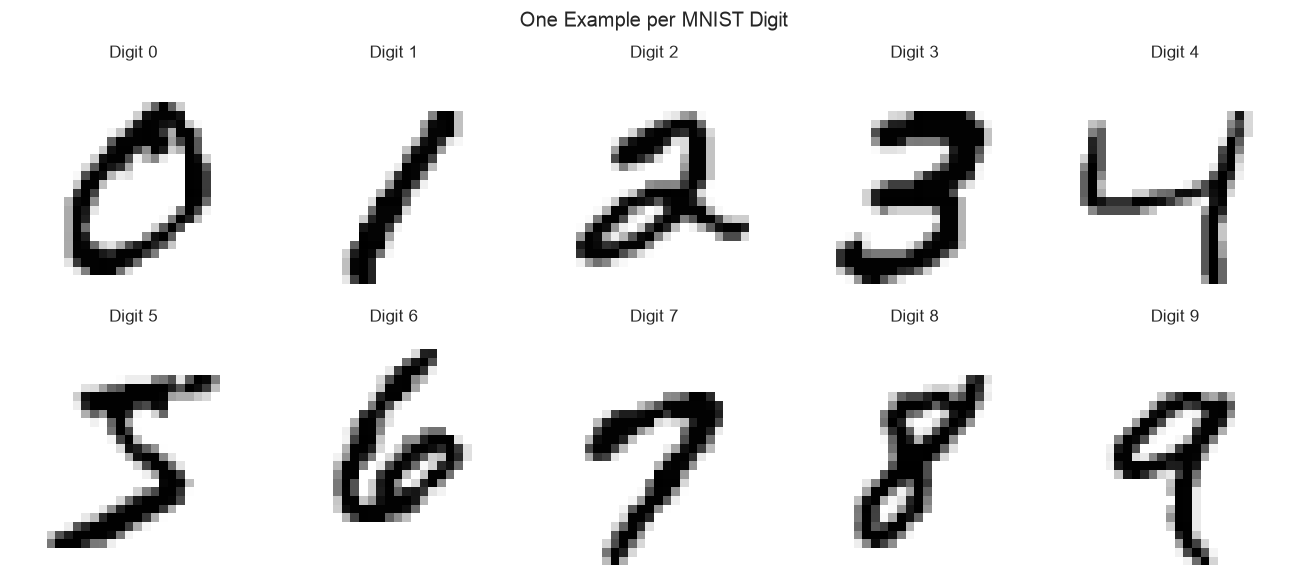

In [3]:
from sklearn.datasets import fetch_openml

mnist_raw = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_raw = mnist_raw.data.astype(np.float64)
y_raw = mnist_raw.target.astype(int)

# Show one example per digit
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digit, ax in enumerate(axes.flat):
    idx = np.where(y_raw == digit)[0][0]
    ax.imshow(X_raw[idx].reshape(28, 28), cmap='gray_r')
    ax.set_title(f'Digit {digit}', fontsize=10)
    ax.axis('off')
plt.suptitle('One Example per MNIST Digit', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mnist_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. PCA variance explained on the subset

Confirm that 50 components are a good reduction.

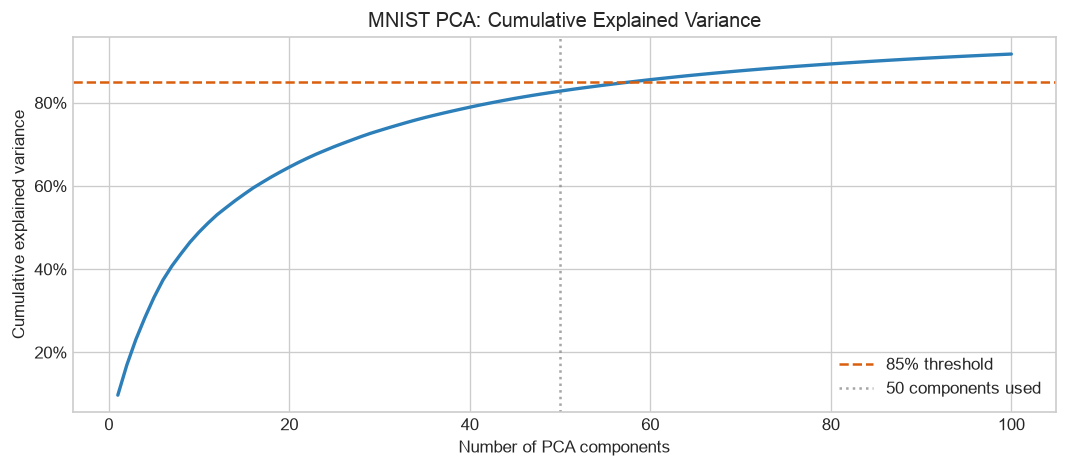

Variance at 50 components: 82.81%


In [4]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_raw), size=5000, replace=False)
X_sub_raw = X_raw[idx] / 255.0

pca_full = PCA(n_components=100, random_state=SEED).fit(X_sub_raw)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, color='#2C7FB8', linewidth=2)
ax.axhline(0.85, linestyle='--', color='#D95F0E', label='85% threshold')
ax.axvline(50, linestyle=':', color='gray', alpha=0.7, label='50 components used')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('MNIST PCA: Cumulative Explained Variance')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mnist_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Variance at 50 components: {cum_var[49]:.2%}')

## 4. Trial experiment: k=10 (one cluster per digit)

k=10 matches the number of digit classes. Each trial is a single restart.

In [5]:
K_MAIN = 10

res_rand = run_trials(X_mnist, k=K_MAIN, init='random',   n_trials=N_TRIALS, base_seed=0)
res_pp   = run_trials(X_mnist, k=K_MAIN, init='plusplus', n_trials=N_TRIALS, base_seed=0)

print('Random    mean={:.2f}  std={:.2f}  min={:.2f}  max={:.2f}'.format(
      res_rand['inertia'].mean(), res_rand['inertia'].std(),
      res_rand['inertia'].min(), res_rand['inertia'].max()))
print('k-means++ mean={:.2f}  std={:.2f}  min={:.2f}  max={:.2f}'.format(
      res_pp['inertia'].mean(), res_pp['inertia'].std(),
      res_pp['inertia'].min(), res_pp['inertia'].max()))

ratio = res_rand['inertia'].mean() / res_pp['inertia'].mean()
print(f'\nRatio random / pp mean inertia: {ratio:.4f}')

Random    mean=152652.59  std=507.36  min=151815.46  max=153759.91
k-means++ mean=152693.84  std=553.47  min=151842.40  max=153942.68

Ratio random / pp mean inertia: 0.9997


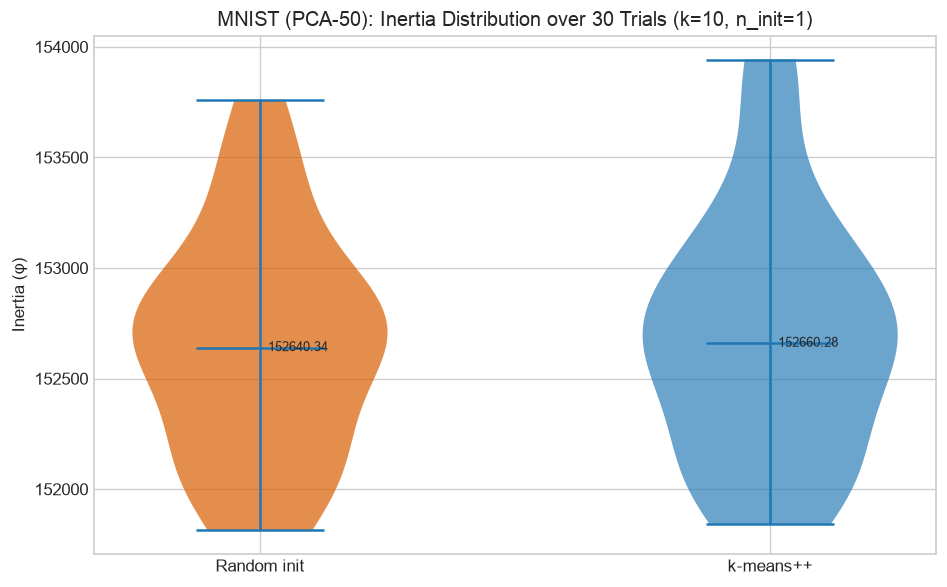

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.violinplot(
    [res_rand['inertia'], res_pp['inertia']],
    positions=[1, 2], showmedians=True, showextrema=True
)
for patch, color in zip(bp['bodies'], ['#d95f02', '#2C7FB8']):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Random init', 'k-means++'])
ax.set_ylabel('Inertia (φ)')
ax.set_title(f'MNIST (PCA-50): Inertia Distribution over {N_TRIALS} Trials (k={K_MAIN}, n_init=1)')
for x, vals in zip([1, 2], [res_rand['inertia'], res_pp['inertia']]):
    ax.text(x, np.median(vals), f'  {np.median(vals):.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mnist_inertia_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. k sweep: k=5, 8, 10, 12, 15

k= 5  random: 173041.71±911.42  pp: 172865.89±804.48
k= 8  random: 158792.12±326.16  pp: 158953.61±362.58
k=10  random: 152681.31±483.23  pp: 152755.30±545.81
k=12  random: 147117.48±565.84  pp: 147250.56±591.09
k=15  random: 140419.93±457.89  pp: 140278.36±471.39


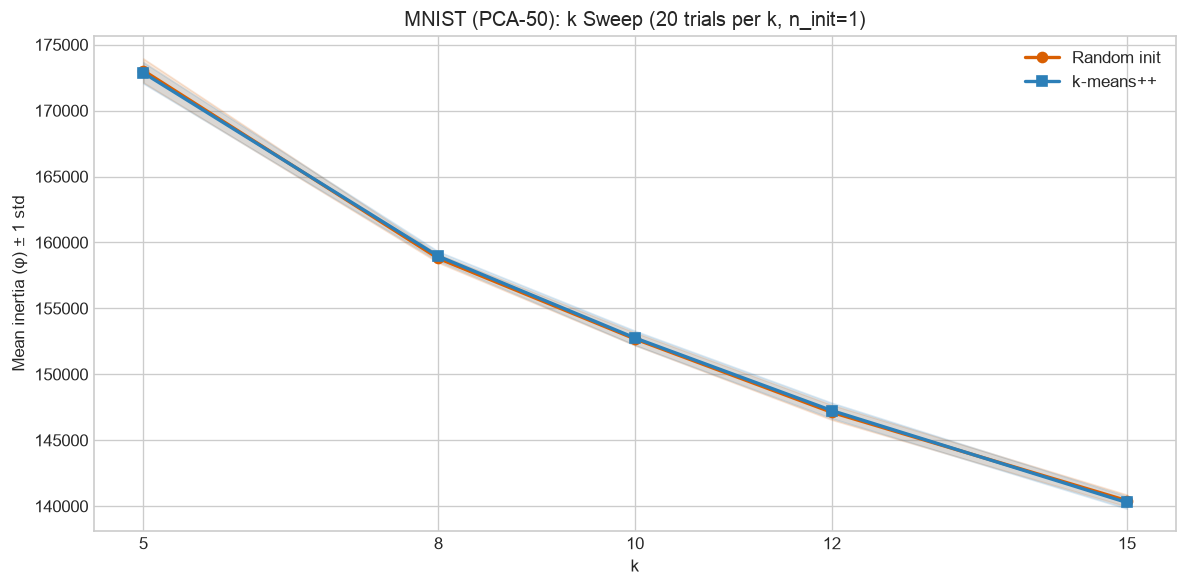

In [7]:
K_SWEEP    = [5, 8, 10, 12, 15]
N_TRIALS_K = 20

means_rand, stds_rand = [], []
means_pp,   stds_pp   = [], []

for k in K_SWEEP:
    r_r = run_trials(X_mnist, k=k, init='random',   n_trials=N_TRIALS_K, base_seed=0)
    r_p = run_trials(X_mnist, k=k, init='plusplus', n_trials=N_TRIALS_K, base_seed=0)
    means_rand.append(r_r['inertia'].mean()); stds_rand.append(r_r['inertia'].std())
    means_pp.append(r_p['inertia'].mean());   stds_pp.append(r_p['inertia'].std())
    print(f'k={k:2d}  random: {means_rand[-1]:.2f}±{stds_rand[-1]:.2f}  '
          f'pp: {means_pp[-1]:.2f}±{stds_pp[-1]:.2f}')

means_rand = np.array(means_rand); stds_rand = np.array(stds_rand)
means_pp   = np.array(means_pp);   stds_pp   = np.array(stds_pp)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_SWEEP, means_rand, 'o-', color='#d95f02', linewidth=2, label='Random init')
ax.fill_between(K_SWEEP, means_rand - stds_rand, means_rand + stds_rand,
                color='#d95f02', alpha=0.15)
ax.plot(K_SWEEP, means_pp, 's-', color='#2C7FB8', linewidth=2, label='k-means++')
ax.fill_between(K_SWEEP, means_pp - stds_pp, means_pp + stds_pp,
                color='#2C7FB8', alpha=0.15)

ax.set_xlabel('k'); ax.set_ylabel('Mean inertia (φ) ± 1 std')
ax.set_title(f'MNIST (PCA-50): k Sweep ({N_TRIALS_K} trials per k, n_init=1)')
ax.set_xticks(K_SWEEP); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mnist_k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cluster purity: sanity check against true digit labels

Purity is **not** a clustering quality metric (it requires labels and increases
trivially with k). It is used here only as a sanity check to confirm that the
k=10 clusters correspond loosely to the true digits.

In [8]:
def cluster_purity(labels_pred: np.ndarray, labels_true: np.ndarray) -> float:
    """Fraction of points whose cluster is dominated by their true class."""
    total_correct = 0
    for c in np.unique(labels_pred):
        mask = labels_pred == c
        if mask.any():
            majority_count = np.bincount(labels_true[mask]).max()
            total_correct += majority_count
    return total_correct / len(labels_pred)


best_model = KMeans(k=K_MAIN, init='plusplus', n_init=10, random_state=SEED)
best_model.fit(X_mnist)

rand_model = KMeans(k=K_MAIN, init='random', n_init=10, random_state=SEED)
rand_model.fit(X_mnist)

purity_pp   = cluster_purity(best_model.labels_, y_mnist)
purity_rand = cluster_purity(rand_model.labels_, y_mnist)

print(f'Purity, k-means++ (best of 10): {purity_pp:.3f}')
print(f'Purity, random   (best of 10): {purity_rand:.3f}')
print(f'Inertia, k-means++: {best_model.inertia_:.3f}')
print(f'Inertia, random:    {rand_model.inertia_:.3f}')

Purity, k-means++ (best of 10): 0.587
Purity, random   (best of 10): 0.560
Inertia, k-means++: 151829.961
Inertia, random:    152172.029


## 7. PCA 2D scatter: cluster structure in reduced space

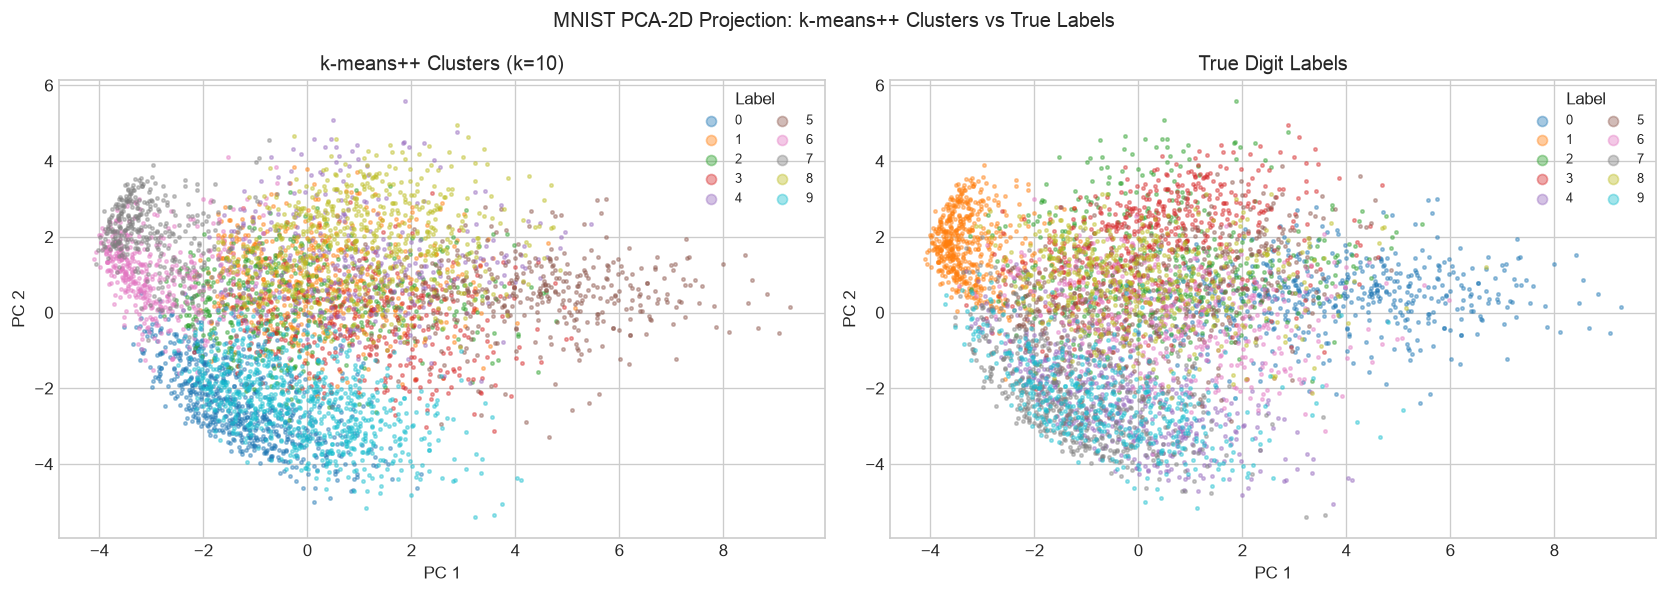

In [9]:
# Project from 50-dim PCA space down to 2D for visualization
pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_mnist)

cmap = plt.get_cmap('tab10')
labels_pp = best_model.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lbl, title in zip(
    axes,
    [labels_pp, y_mnist],
    ['k-means++ Clusters (k=10)', 'True Digit Labels']
):
    for c in range(10):
        mask = lbl == c
        ax.scatter(pca_2d[mask, 0], pca_2d[mask, 1],
                   s=4, alpha=0.4, color=cmap(c), label=str(c))
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    ax.set_title(title)
    ax.legend(title='Label', markerscale=3, fontsize=8, ncol=2)

plt.suptitle('MNIST PCA-2D Projection: k-means++ Clusters vs True Labels', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mnist_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Metric | Random init | k-means++ |
|---|---|---|
| Mean inertia (30 trials, n_init=1) | 152,652.6 | 152,693.8 |
| Std of inertia | 507.4 | 553.5 |
| Purity (best of 10 restarts) | 56.0% | **58.7%** |

**Key finding**: In 50-dimensional PCA space with k=10, the inertia values
for random and k-means++ are statistically indistinguishable (ratio ≈ 1.000).
However, cluster purity tells a different story: k-means++ aligns better with
the true digit structure (58.7% vs 56.0%), suggesting it finds a qualitatively
different local minimum that better respects the underlying manifold geometry.
This dissociation (similar inertia, better label alignment) is an important
nuance not captured by the theoretical bound alone (Theorem 3.1, Section 3).